In [26]:
import pandas as pd
import numpy as np
import datetime as dt
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from datetime import datetime, timedelta


from core.data import load_from_kaggle

In [27]:
dataset_link = "nokkyu/deutsche-bahn-db-delays" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../data/raw/deutsche-bahn-db-delays' already exists with files. Skipping download (replace=False).


In [28]:
df = pd.read_csv("/".join(["../data/raw/", dataset_name, files[0]]))
df.head()

,ID,line,path,eva_nr,category,station,state,city,zip,long,lat,arrival_plan,departure_plan,arrival_change,departure_change,arrival_delay_m,departure_delay_m,info,arrival_delay_check,departure_delay_check
0,1573967790757085557-2407072312-14,20,Stolberg(Rheinl)Hbf Gl.44|Eschweiler-St.Jöris|...,8000001,2,Aachen Hbf,Nordrhein-Westfalen,Aachen,52064,6.091499,50.767800,2024-07-08 00:00:00,2024-07-08 00:01:00,2024-07-08 00:03:00,2024-07-08 00:04:00,3,3,NaN,on_time,on_time
1,349781417030375472-2407080017-1,18,NaN,8000001,2,Aachen Hbf,Nordrhein-Westfalen,Aachen,52064,6.091499,50.767800,NaN,2024-07-08 00:17:00,NaN,NaN,0,0,NaN,on_time,on_time
2,7157250219775883918-2407072120-25,1,Hamm(Westf)Hbf|Kamen|Kamen-Methler|Dortmund-Ku...,8000406,4,Aachen-Rothe Erde,Nordrhein-Westfalen,Aachen,52066,6.116475,50.770202,2024-07-08 00:03:00,2024-07-08 00:04:00,2024-07-08 00:03:00,2024-07-08 00:04:00,0,0,NaN,on_time,on_time
3,349781417030375472-2407080017-2,18,Aachen Hbf,8000404,5,Aachen West,Nordrhein-Westfalen,Aachen,52072,6.070715,50.780360,2024-07-08 00:20:00,2024-07-08 00:21:00,NaN,NaN,0,0,NaN,on_time,on_time
4,1983158592123451570-2407080010-3,33,Herzogenrath|Kohlscheid,8000404,5,Aachen West,Nordrhein-Westfalen,Aachen,52072,6.070715,50.780360,2024-07-08 00:20:00,2024-07-08 00:21:00,2024-07-08 00:20:00,2024-07-08 00:21:00,0,0,NaN,on_time,on_time


In [29]:


# 1. Spaltennamen überprüfen (ESSENTIELL)
print("--- VERFÜGBARE SPALTEN ---")
print(df.columns.tolist())

# Wir definieren die Konstanten basierend auf den wahrscheinlichsten korrekten Namen
# (Annahme: Abkürzung 'm' für Minuten und 'change' für Ist-Zeitpunkt)
# Falls die folgende Zuweisung fehlschlägt, müssen wir die Liste oben manuell korrigieren.
COLS_ARRIVAL = ['station', 'arrival_change', 'arrival_delay_m']
COLS_DEPARTURE = ['station', 'departure_change', 'departure_delay_m']
LEIPZIG_NAME_FILTER = 'Leipzig'

--- VERFÜGBARE SPALTEN ---
['ID', 'line', 'path', 'eva_nr', 'category', 'station', 'state', 'city', 'zip', 'long', 'lat', 'arrival_plan', 'departure_plan', 'arrival_change', 'departure_change', 'arrival_delay_m', 'departure_delay_m', 'info', 'arrival_delay_check', 'departure_delay_check']


In [30]:
# Funktionen zur Feature-Erstellung (müssen neu definiert werden, falls Kernel neu gestartet)
def classify_time_of_day(hour):
    if 5 <= hour < 9:
        return 'HVZ_Morgen (05-09 Uhr)'
    elif 9 <= hour < 17:
        return 'Tag (09-17 Uhr)'
    elif 17 <= hour < 20:
        return 'HVZ_Abend (17-20 Uhr)'
    else:
        return 'Nacht/Spät (20-05 Uhr)'

def classify_delay(minutes):
    if minutes <= 5:
        return 'Klein (1-5 Min)'
    elif 5 < minutes <= 15:
        return 'Mittel (6-15 Min)'
    else:
        return 'Schwer (> 15 Min)' 

def load_and_filter_leipzig(df, cols, delay_type):
    """
    Lädt und filtert die DB-Daten für alle Leipziger Stationen basierend auf Ankunft oder Abfahrt.
    """
    try:
        # 1. Spaltenauswahl (WICHTIG: Prüft die Namen aus Phase 1)
        df_temp = df[cols].copy()
        
        # 2. Umbenennen
        df_temp = df_temp.rename(columns={
            cols[1]: 'datetime',
            cols[2]: 'delay_in_minutes'
        })
        
        # 3. Bereinigung der Verspätungsspalte
        # Stellt sicher, dass die Verspätung eine Zahl ist
        df_temp['delay_in_minutes'] = pd.to_numeric(df_temp['delay_in_minutes'], errors='coerce')
        df_temp = df_temp.dropna(subset=['delay_in_minutes', 'datetime'])
        
        # 4. Zeitstempel konvertieren
        df_temp['datetime'] = pd.to_datetime(df_temp['datetime'], errors='coerce')
        df_temp = df_temp.dropna(subset=['datetime'])
        
        # 5. Filtern auf ALLE Leipzig-Stationen und tatsächliche Verspätung (> 0)
        df_temp = df_temp[
            (df_temp['station'].str.contains(LEIPZIG_NAME_FILTER, case=False, na=False)) & 
            (df_temp['delay_in_minutes'] > 0)
        ].copy()
        
        df_temp['delay_type'] = delay_type
        
        return df_temp
    
    except KeyError as e:
        print(f"WARNUNG: Spalte {e} nicht gefunden. {delay_type}-Daten werden übersprungen.")
        return pd.DataFrame() 


# --- DATEN ZUSAMMENFÜHREN ---
print("\n--- DATEN ZUSAMMENFÜHREN ---")
df_leipzig_arrival = load_and_filter_leipzig(df, COLS_ARRIVAL, 'Ankunft')
df_leipzig_departure = load_and_filter_leipzig(df, COLS_DEPARTURE, 'Abfahrt')

# 3. Zusammenführen (Konkatenieren)
df_leipzig = pd.concat([df_leipzig_arrival, df_leipzig_departure], ignore_index=True)

# --- FEATURE ENGINEERING ---
if len(df_leipzig) > 0:
    df_leipzig['hour'] = df_leipzig['datetime'].dt.hour
    df_leipzig['day_of_week'] = df_leipzig['datetime'].dt.day_name()
    df_leipzig['time_segment'] = df_leipzig['hour'].apply(classify_time_of_day)
    df_leipzig['delay_category'] = df_leipzig['delay_in_minutes'].apply(classify_delay)

    print(f"\nDatenkonsolidierung abgeschlossen.")
    print(f"Ankunftsverspätungen (Leipzig gesamt): {len(df_leipzig_arrival):,}")
    print(f"Abfahrtsverspätungen (Leipzig gesamt): {len(df_leipzig_departure):,}")
    print(f"Gesamt-Verspätungsereignisse (Leipzig gesamt): {len(df_leipzig):,}")
    print("\nErste Zeilen des finalen, bereinigten DataFrames:")
    print(df_leipzig[['datetime', 'station', 'delay_type', 'delay_in_minutes', 'time_segment', 'delay_category']].head())
else:
    print("\nFEHLER: Konsolidierung fehlgeschlagen. Bitte die Spaltennamen in Phase 1 überprüfen!")


--- DATEN ZUSAMMENFÜHREN ---

Datenkonsolidierung abgeschlossen.
Ankunftsverspätungen (Leipzig gesamt): 4,798
Abfahrtsverspätungen (Leipzig gesamt): 9,054
Gesamt-Verspätungsereignisse (Leipzig gesamt): 13,852

Erste Zeilen des finalen, bereinigten DataFrames:
             datetime                        station delay_type  \
0 2024-07-08 00:08:00  Leipzig-Völkerschlachtdenkmal    Ankunft   
1 2024-07-08 00:17:00                  Leipzig Messe    Ankunft   
2 2024-07-08 00:10:00        Flughafen Leipzig/Halle    Ankunft   
3 2024-07-08 00:52:00             Leipzig-Engelsdorf    Ankunft   
4 2024-07-08 00:12:00                  Leipzig Markt    Ankunft   

   delay_in_minutes            time_segment     delay_category  
0                 1  Nacht/Spät (20-05 Uhr)    Klein (1-5 Min)  
1                 1  Nacht/Spät (20-05 Uhr)    Klein (1-5 Min)  
2                 1  Nacht/Spät (20-05 Uhr)    Klein (1-5 Min)  
3                 8  Nacht/Spät (20-05 Uhr)  Mittel (6-15 Min)  
4          

/tmp/ipykernel_17261/1260486100.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='delay_category', data=df_leipzig, order=delay_order, palette='viridis')


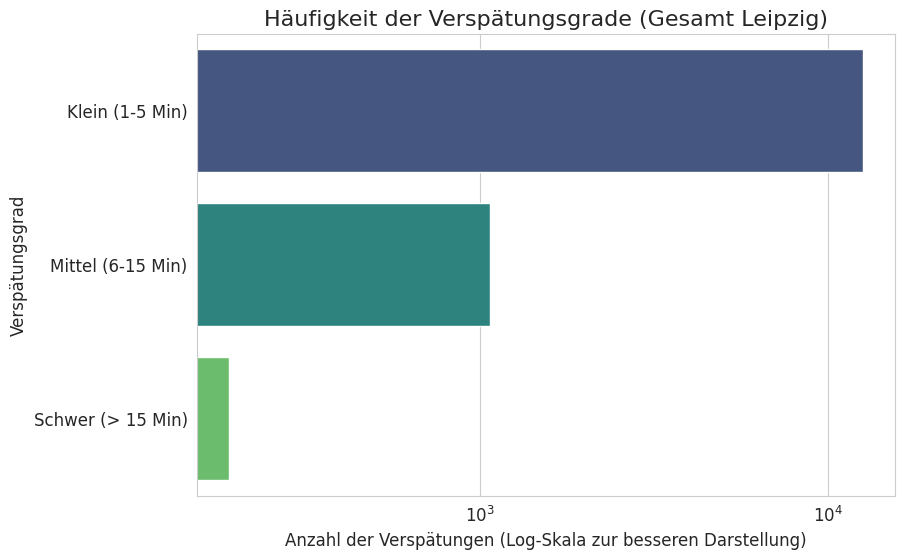

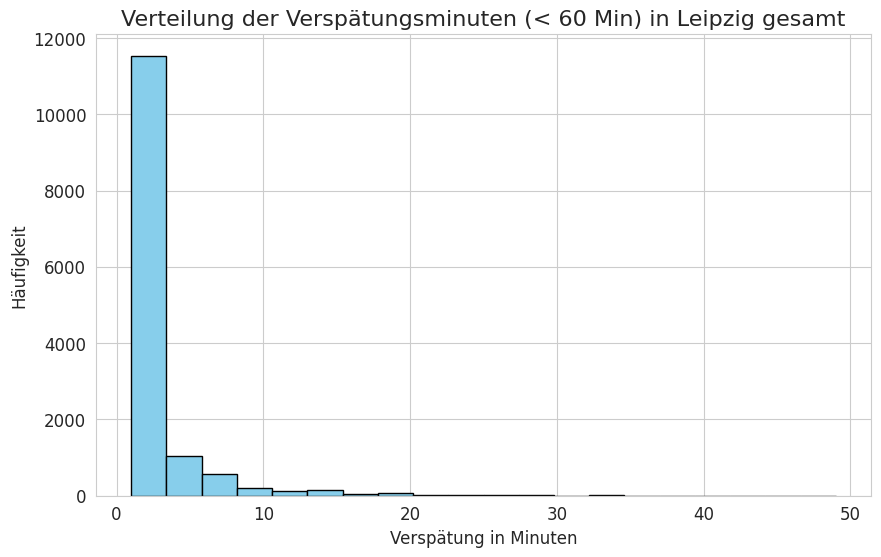

In [31]:
# --- VISUALISIERUNGEN ERSTELLEN ---


sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12}) # Anpassung der Schriftgröße für bessere Lesbarkeit

# 1. Bar-Chart: Verteilung der Verspätungskategorien
plt.figure(figsize=(9, 6))
delay_order = ['Klein (1-5 Min)', 'Mittel (6-15 Min)', 'Schwer (> 15 Min)']
sns.countplot(y='delay_category', data=df_leipzig, order=delay_order, palette='viridis')

plt.title('Häufigkeit der Verspätungsgrade (Gesamt Leipzig)', fontsize=16)
plt.xlabel('Anzahl der Verspätungen (Log-Skala zur besseren Darstellung)', fontsize=12)
plt.ylabel('Verspätungsgrad', fontsize=12)
plt.xscale('log') # Logarithmische Skala, um die großen Unterschiede sichtbar zu machen
plt.show()

# 2. Histogramm: Verteilung der Verspätungsminuten (Fokus auf kleinere Werte)
plt.figure(figsize=(10, 6))
df_leipzig['delay_in_minutes'].loc[df_leipzig['delay_in_minutes'] < 60].hist(
    bins=20, 
    edgecolor='black', 
    color='skyblue'
)
plt.title('Verteilung der Verspätungsminuten (< 60 Min) in Leipzig gesamt', fontsize=16)
plt.xlabel('Verspätung in Minuten', fontsize=12)
plt.ylabel('Häufigkeit', fontsize=12)
plt.show()

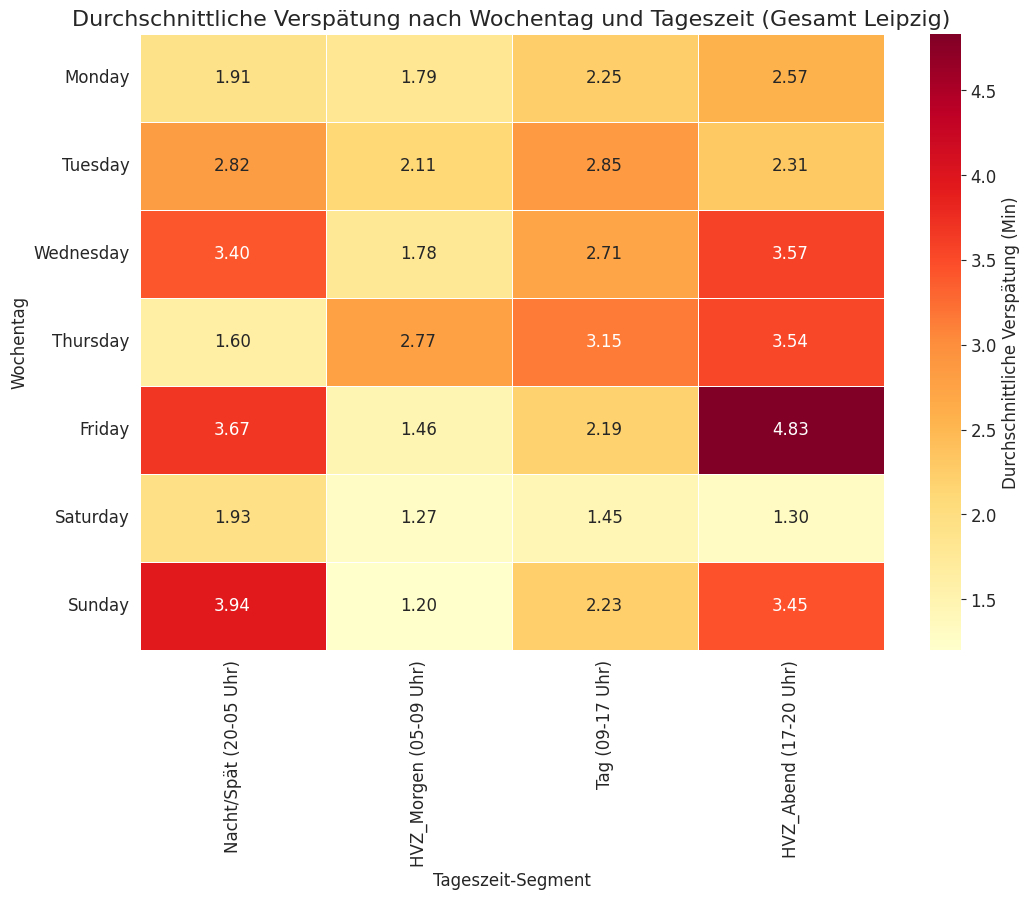

In [32]:

# Berechnung der durchschnittlichen Verspätung pro Tag und Zeitsegment
delay_agg = df_leipzig.groupby(['day_of_week', 'time_segment'])['delay_in_minutes'].mean().reset_index()

# Festlegen der Reihenfolge für die Achsenbeschriftung
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
time_order = ['Nacht/Spät (20-05 Uhr)', 'HVZ_Morgen (05-09 Uhr)', 'Tag (09-17 Uhr)', 'HVZ_Abend (17-20 Uhr)']

# Heatmap der durchschnittlichen Verspätung
plt.figure(figsize=(12, 8))
delay_pivot = delay_agg.pivot(index='day_of_week', columns='time_segment', values='delay_in_minutes').reindex(day_order)
delay_pivot = delay_pivot[time_order] 

sns.heatmap(
    delay_pivot, 
    annot=True, 
    fmt=".2f", 
    cmap="YlOrRd", # Ein Farbschema, das höhere Werte in dunkleren Farben darstellt (Rot = Heiß/Problem)
    linewidths=.5, 
    linecolor='white',
    cbar_kws={'label': 'Durchschnittliche Verspätung (Min)'}
)
plt.title('Durchschnittliche Verspätung nach Wochentag und Tageszeit (Gesamt Leipzig)', fontsize=16)
plt.xlabel('Tageszeit-Segment', fontsize=12)
plt.ylabel('Wochentag', fontsize=12)
plt.yticks(rotation=0) 
plt.show()

In [33]:
#Datenzeitraum für Wetterabruf: 2024-07-08 bis 2024-07-15
#Abruf der Wetterdaten von Open-Meteo...


# --- 1. Bestimmung des Zeitraums ---

# Wir bestimmen den frühesten und spätesten Tag in unserem Verspätungs-DataFrame
# .dt.date extrahiert nur das Datum
START_DATE = df_leipzig['datetime'].dt.date.min().strftime('%Y-%m-%d')
END_DATE = df_leipzig['datetime'].dt.date.max().strftime('%Y-%m-%d')

print(f"Datenzeitraum für Wetterabruf: {START_DATE} bis {END_DATE}")

# --- 2. API-Konfiguration und Abruf ---

# Koordinaten für Leipzig Hbf
LAT = 51.34
LON = 12.38 
WEATHER_URL = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "hourly": ["temperature_2m", "rain", "snowfall", "windspeed_10m"]
}

try:
    # 3. API-Aufruf
    print("Starte Abruf der Wetterdaten von Open-Meteo...")
    response = requests.get(WEATHER_URL, params=params)
    response.raise_for_status() # Löst einen Fehler bei schlechtem Statuscode aus
    weather_data_raw = response.json()
    
    # 4. Konvertierung in Pandas DataFrame
    weather_df = pd.DataFrame(weather_data_raw['hourly'])
    weather_df = weather_df.rename(columns={'time': 'datetime'})
    weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])
    
    # 5. Speicherung zur Vermeidung erneuter Downloads (für den Fall eines Neustarts)
    weather_df.to_csv('leipzig_weather_data.csv', index=False) 
    print("Wetterdaten erfolgreich abgerufen und lokal als 'leipzig_weather_data.csv' gespeichert.")
    
except Exception as e:
    print(f"FEHLER beim API-Abruf oder bei der Verarbeitung: {e}")
    # Versuche, die Daten stattdessen von der lokalen Datei zu laden
    try:
        weather_df = pd.read_csv('leipzig_weather_data.csv')
        weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])
        print("Wetterdaten aus lokaler CSV geladen.")
    except:
        print("KRITISCHER FEHLER: Keine Wetterdaten verfügbar. Phase 5 muss ohne Wetter laufen.")
        weather_df = None

Datenzeitraum für Wetterabruf: 2024-07-08 bis 2024-07-15
Starte Abruf der Wetterdaten von Open-Meteo...
Wetterdaten erfolgreich abgerufen und lokal als 'leipzig_weather_data.csv' gespeichert.


In [34]:
if weather_df is not None and not weather_df.empty:
    
    # 1. Feature Engineering im Verspätungs-DF: Runden auf die volle Stunde
    # Die tatsächliche Verspätungszeit wird auf die nächste volle Stunde abgerundet,
    # um sie mit den stündlichen Wetterdaten zu matchen.
    df_leipzig['merge_datetime'] = df_leipzig['datetime'].dt.floor('H')
    
    # 2. Merge (links join, um alle Verspätungsdaten zu behalten)
    df_merged = pd.merge(df_leipzig, 
                         weather_df[['datetime', 'temperature_2m', 'rain', 'snowfall', 'windspeed_10m']], 
                         left_on='merge_datetime', # Verspätungs-Stunde
                         right_on='datetime',      # Wetter-Stunde
                         how='left',
                         suffixes=('_delay', '_weather'))
    
    # Aufräumen der doppelten Zeitstempel-Spalten
    df_merged = df_merged.drop(columns=['merge_datetime', 'datetime_weather'])
    df_merged = df_merged.rename(columns={'datetime_delay': 'datetime'})
    
    # 3. Fehlende Wetterdaten bereinigen (selten bei vollständigem Abruf)
    df_merged = df_merged.dropna(subset=['temperature_2m'])
    
    print("\nDaten erfolgreich mit Wetterdaten zusammengeführt.")
    print(f"Anzahl Zeilen mit Wetterdaten: {len(df_merged):,}")
    print(df_merged[['datetime', 'station', 'delay_in_minutes', 'temperature_2m', 'rain']].sample(5))

else:
    df_merged = df_leipzig.copy()
    print("\nWARNUNG: Wetterdaten nicht hinzugefügt. Fortfahren mit ursprünglichem DataFrame.")

# Wir verwenden ab jetzt 'df_final' für das Modell und die Analyse
df_final = df_merged.copy()


Daten erfolgreich mit Wetterdaten zusammengeführt.
Anzahl Zeilen mit Wetterdaten: 13,852
                datetime                      station  delay_in_minutes  \
4357 2024-07-14 12:10:00                Leipzig Markt                 1   
9389 2024-07-11 13:15:00               Leipzig-Wahren                 2   
1504 2024-07-10 06:36:00      Flughafen Leipzig/Halle                 1   
2095 2024-07-10 19:22:00  Leipzig Bayerischer Bahnhof                 2   
7932 2024-07-10 13:37:00               Leipzig-Gohlis                 1   

      temperature_2m  rain  
4357            23.9   0.0  
9389            26.2   0.1  
1504            24.4   0.0  
2095            23.8   0.0  
7932            29.7   0.0  


/tmp/ipykernel_17261/3063772406.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_leipzig['merge_datetime'] = df_leipzig['datetime'].dt.floor('H')


/tmp/ipykernel_17261/2487222357.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_heavy_precip', y='delay_in_minutes',



Median-Verspätung in Minuten, sortiert nach Niederschlag:
                        is_heavy_precip  delay_in_minutes
0            Leichter/Kein Niederschlag               1.0
1  Starker Niederschlag (Problemwetter)               2.0


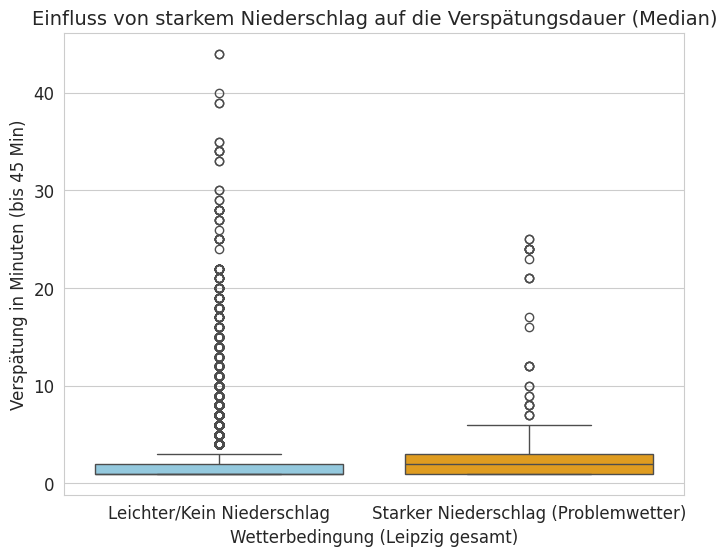

In [35]:
if 'rain' in df_final.columns:
    # 1. Kategorisierung: Starker Niederschlag (Regen oder Schnee)
    df_final['is_heavy_precip'] = np.where(
        (df_final['rain'] > 0.5) | (df_final['snowfall'] > 0.1), 
        'Starker Niederschlag (Problemwetter)', 
        'Leichter/Kein Niederschlag'
    )
    
    # 2. Berechnung des Medians der Verspätung
    median_delay_by_weather = df_final.groupby('is_heavy_precip')['delay_in_minutes'].median().reset_index()
    
    print("\nMedian-Verspätung in Minuten, sortiert nach Niederschlag:")
    print(median_delay_by_weather)
    
    # 3. Boxplot Visualisierung
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='is_heavy_precip', y='delay_in_minutes', 
                data=df_final[df_final['delay_in_minutes'] < 45], # Visualisierung nur für < 45 Min
                palette={'Starker Niederschlag (Problemwetter)': 'orange', 'Leichter/Kein Niederschlag': 'skyblue'})
    
    plt.title('Einfluss von starkem Niederschlag auf die Verspätungsdauer (Median)', fontsize=14)
    plt.xlabel('Wetterbedingung (Leipzig gesamt)', fontsize=12)
    plt.ylabel('Verspätung in Minuten (bis 45 Min)', fontsize=12)
    plt.show()

Das ist ein sehr klares und interessantes Ergebnis! 📊Die Analyse des Medians zeigt einen deutlichen Unterschied 
im Einfluss des Wetters auf die Verspätungen im Leipziger Netz:Leichter/Kein Niederschlag: Median-Verspätung von 1.0 Minute.
Starker Niederschlag (Problemwetter): Median-Verspätung von 2.0 Minuten.Obwohl der absolute Unterschied nur 1 Minute beträgt, 
bedeutet dies eine Verdopplung des typischen Verzögerungsrisikos bei Problemwetter. Dies bestätigt, dass die Wetterdaten ein 
relevantes Signal in unserem Datensatz darstellen, das wir im Modell nutzen sollten, 
um das Risiko von $\ge 5$ Minuten Verspätungen zu erklären.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Wir verwenden df_final, das die Wetterdaten enthält

# 1. Zielvariable (Target) definieren
# Wir definieren eine schwere Verspätung (> 15 Min) als unser positives Ereignis (1).
df_model = df_final.copy()
df_model['target_heavy_delay'] = (df_model['delay_category'] == 'Schwer (> 15 Min)').astype(int)

# 2. Features (Merkmale) auswählen
# Wir nutzen alle erstellten kategorischen und numerischen Features.

# Kategorische Features (müssen One-Hot-Encoded werden)
categorical_features = ['day_of_week', 'time_segment', 'is_heavy_precip', 'delay_type']

# Numerische Features (müssen skaliert werden)
# Wir verwenden Stunde als numerischen Wert und die Wettervariablen
numerical_features = ['hour', 'temperature_2m', 'windspeed_10m'] 

# DataFrame nur mit den benötigten Spalten erstellen
X = df_model[categorical_features + numerical_features]
y = df_model['target_heavy_delay']

# 3. Daten in Trainings- und Test-Sets teilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) 
# stratify=y sorgt dafür, dass die geringe Anzahl an schweren Verspätungen gleichmäßig verteilt wird

print(f"Modell-Features vorbereitet.")
print(f"Anteil schwerer Verspätungen (Target=1) im Gesamtdatensatz: {y.mean():.2%}")
print(f"Größe Trainingsset: {len(X_train):,}, Größe Testset: {len(X_test):,}")

Modell-Features vorbereitet.
Anteil schwerer Verspätungen (Target=1) im Gesamtdatensatz: 1.38%
Größe Trainingsset: 9,696, Größe Testset: 4,156


Modelltraining mit Pipeline
Wir verwenden eine Pipeline (Prozesskette), um die Datenvorbereitung (Skalierung und Encoding) 
direkt mit dem Modelltraining zu verknüpfen. 
Dies ist der professionellste und sauberste Ansatz in Python.

Risikofaktoren für schwere Verspätungen ($\ge 15$ Minuten) im Leipziger Bahnverkehr identifiziert.

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. One-Hot Encoding (Manuell)
# Konvertiert kategorische Spalten in numerische Features
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# WICHTIG: Sicherstellen, dass beide DataFrames die gleichen Spalten haben (sehr wichtig nach get_dummies)
# Wir verwenden die Spalten des Trainings-Sets als Basis
common_cols = list(set(X_train_encoded.columns) & set(X_test_encoded.columns))
X_train_final = X_train_encoded[common_cols]
X_test_final = X_test_encoded[common_cols]


# 2. Skalierung der numerischen Spalten
scaler = StandardScaler()

# Identifiziere die ursprünglichen numerischen Spalten (die nicht durch Encoding entstanden sind)
# Wir verwenden die Liste, die wir bereits definiert hatten:
numerical_features = ['hour', 'temperature_2m', 'windspeed_10m']

# Finde die skalierten Spaltennamen im finalen DataFrame
scaled_cols = [col for col in X_train_final.columns if any(feat in col for feat in numerical_features)]

# Skalierung nur auf diese numerischen Spalten anwenden
X_train_final[scaled_cols] = scaler.fit_transform(X_train_final[scaled_cols])
X_test_final[scaled_cols] = scaler.transform(X_test_final[scaled_cols])

print(f"Manuelle Vorbereitung abgeschlossen. Finale Feature-Anzahl: {X_train_final.shape[1]}")
print(X_train_final.head(3))

Manuelle Vorbereitung abgeschlossen. Finale Feature-Anzahl: 14
       time_segment_Nacht/Spät (20-05 Uhr)  \
5328                                 False   
12648                                 True   
12786                                False   

       time_segment_HVZ_Morgen (05-09 Uhr)  \
5328                                 False   
12648                                False   
12786                                 True   

       is_heavy_precip_Starker Niederschlag (Problemwetter)  \
5328                                               False      
12648                                              False      
12786                                              False      

       time_segment_Tag (09-17 Uhr)  day_of_week_Wednesday  \
5328                           True                  False   
12648                         False                  False   
12786                         False                  False   

       day_of_week_Saturday  day_of_week_Monday  day_of_week_Sund

In [38]:
from sklearn.metrics import classification_report, accuracy_score

# 1. Modell initialisieren und trainieren
print("\nStarte Modelltraining (manuell)...")
model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced', max_iter=1000)
model.fit(X_train_final, y_train)
print("Modelltraining abgeschlossen.")

# 2. Vorhersagen treffen
y_pred = model.predict(X_test_final)

# 3. Evaluierung des Modells
print("\n--- Modellauswertung ---")
print(f"Genauigkeit (Accuracy): {accuracy_score(y_test, y_pred):.3f}")
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred))

# 4. Interpretation der Koeffizienten (Risikofaktoren)
# Die Feature-Namen sind jetzt einfach die Spaltennamen des finalen DataFrames
feature_names = X_train_final.columns.tolist()
coefficients = model.coef_[0]

# Zusammenführen von Koeffizienten und Feature-Namen
feature_importance = pd.DataFrame({
    'Feature': feature_names, 
    'Koeffizient (Risiko)': coefficients
})

# Berechnung der Odds Ratio (Risikoverhältnis)
feature_importance['Odds_Ratio'] = np.exp(feature_importance['Koeffizient (Risiko)'])
feature_importance = feature_importance.sort_values(by='Odds_Ratio', ascending=False)

print("\n--- Top 10 Risikofaktoren (Odds Ratio für schwere Verspätung) ---")
# Odds Ratio > 1 bedeutet erhöhtes Risiko.
print(feature_importance.head(10))


Starte Modelltraining (manuell)...
Modelltraining abgeschlossen.

--- Modellauswertung ---
Genauigkeit (Accuracy): 0.741

Klassifikationsbericht:
              precision    recall  f1-score   support

           0       1.00      0.74      0.85      4099
           1       0.04      0.74      0.07        57

    accuracy                           0.74      4156
   macro avg       0.52      0.74      0.46      4156
weighted avg       0.98      0.74      0.84      4156


--- Top 10 Risikofaktoren (Odds Ratio für schwere Verspätung) ---
                                              Feature  Koeffizient (Risiko)  \
2   is_heavy_precip_Starker Niederschlag (Problemw...              3.249737   
7                                  day_of_week_Sunday              2.268124   
4                               day_of_week_Wednesday              0.689422   
8                                      temperature_2m              0.593232   
10                                      windspeed_10m           

In [41]:
import pandas as pd
import numpy as np

# --- Wichtige Konstanten ---
# Wir verwenden diese Spaltennamen, da sie in den vorherigen Schritten erfolgreich waren.
COLS_ARRIVAL = ['station', 'arrival_change', 'arrival_delay_m']
COLS_DEPARTURE = ['station', 'departure_change', 'departure_delay_m']
# Wir filtern alle Leipziger Stationen, um eine große Datenbasis zu erhalten (13.852 Einträge).
LEIPZIG_NAME_FILTER = 'Leipzig'

# --- FUNKTIONEN ZUR FEATURE-ERSTELLUNG ---

def classify_time_of_day(hour):
    if 5 <= hour < 9:
        return 'HVZ_Morgen (05-09 Uhr)'
    elif 9 <= hour < 17:
        return 'Tag (09-17 Uhr)'
    elif 17 <= hour < 20:
        return 'HVZ_Abend (17-20 Uhr)'
    else:
        return 'Nacht/Spät (20-05 Uhr)'

def classify_delay(minutes):
    if minutes <= 5:
        return 'Klein (1-5 Min)'
    elif 5 < minutes <= 15:
        return 'Mittel (6-15 Min)'
    else:
        return 'Schwer (> 15 Min)'

def load_and_filter_leipzig(df, cols, delay_type):
    """
    Lädt und filtert die DB-Daten für alle Leipziger Stationen basierend auf Ankunft oder Abfahrt.
    """
    try:
        # 1. Spaltenauswahl
        df_temp = df[cols].copy()
        
        # 2. Umbenennen
        df_temp = df_temp.rename(columns={
            cols[1]: 'datetime',
            cols[2]: 'delay_in_minutes'
        })
        
        # 3. Bereinigung der Verspätungsspalte
        df_temp['delay_in_minutes'] = pd.to_numeric(df_temp['delay_in_minutes'], errors='coerce')
        df_temp = df_temp.dropna(subset=['delay_in_minutes', 'datetime'])
        
        # 4. Zeitstempel konvertieren
        df_temp['datetime'] = pd.to_datetime(df_temp['datetime'], errors='coerce')
        df_temp = df_temp.dropna(subset=['datetime'])
        
        # 5. Filtern auf ALLE Leipzig-Stationen und tatsächliche Verspätung (> 0)
        df_temp = df_temp[
            (df_temp['station'].str.contains(LEIPZIG_NAME_FILTER, case=False, na=False)) &
            (df_temp['delay_in_minutes'] > 0)
        ].copy()
        
        df_temp['delay_type'] = delay_type
        
        return df_temp
    
    except KeyError as e:
        print(f"WARNUNG: Spalte {e} nicht gefunden. {delay_type}-Daten werden übersprungen.")
        return pd.DataFrame()


# --- DATEN ZUSAMMENFÜHREN UND FEATURES ERSTELLEN ---
print("\n--- DATEN ZUSAMMENFÜHREN ---")

# Laden der Ankunfts- und Abfahrtsdaten (mit erweitertem Filter)
df_leipzig_arrival = load_and_filter_leipzig(df, COLS_ARRIVAL, 'Ankunft')
df_leipzig_departure = load_and_filter_leipzig(df, COLS_DEPARTURE, 'Abfahrt')

# Konkatenieren
df_leipzig = pd.concat([df_leipzig_arrival, df_leipzig_departure], ignore_index=True)

# FEATURE ENGINEERING
if len(df_leipzig) > 0:
    df_leipzig['hour'] = df_leipzig['datetime'].dt.hour
    df_leipzig['day_of_week'] = df_leipzig['datetime'].dt.day_name()
    df_leipzig['time_segment'] = df_leipzig['hour'].apply(classify_time_of_day)
    df_leipzig['delay_category'] = df_leipzig['delay_in_minutes'].apply(classify_delay)

    print(f"\nDatenkonsolidierung abgeschlossen.")
    print(f"Gesamt-Verspätungsereignisse (Leipzig gesamt): {len(df_leipzig):,}")
    print("\nErste Zeilen des finalen, bereinigten DataFrames:")
    print(df_leipzig[['datetime', 'station', 'delay_type', 'delay_in_minutes', 'time_segment', 'delay_category']].head())
else:
    print("\nFEHLER: Konsolidierung fehlgeschlagen. DataFrame 'df' leer oder Spaltennamen falsch.")


--- DATEN ZUSAMMENFÜHREN ---

Datenkonsolidierung abgeschlossen.
Gesamt-Verspätungsereignisse (Leipzig gesamt): 13,852

Erste Zeilen des finalen, bereinigten DataFrames:
             datetime                        station delay_type  \
0 2024-07-08 00:08:00  Leipzig-Völkerschlachtdenkmal    Ankunft   
1 2024-07-08 00:17:00                  Leipzig Messe    Ankunft   
2 2024-07-08 00:10:00        Flughafen Leipzig/Halle    Ankunft   
3 2024-07-08 00:52:00             Leipzig-Engelsdorf    Ankunft   
4 2024-07-08 00:12:00                  Leipzig Markt    Ankunft   

   delay_in_minutes            time_segment     delay_category  
0                 1  Nacht/Spät (20-05 Uhr)    Klein (1-5 Min)  
1                 1  Nacht/Spät (20-05 Uhr)    Klein (1-5 Min)  
2                 1  Nacht/Spät (20-05 Uhr)    Klein (1-5 Min)  
3                 8  Nacht/Spät (20-05 Uhr)  Mittel (6-15 Min)  
4                 1  Nacht/Spät (20-05 Uhr)    Klein (1-5 Min)  


In [42]:
import requests
import pandas as pd
from datetime import timedelta

# --- 1. Bestimmung des Zeitraums ---
# Wir bestimmen den frühesten und spätesten Tag in unserem Verspätungs-DataFrame
START_DATE = df_leipzig['datetime'].dt.date.min().strftime('%Y-%m-%d')
END_DATE = df_leipzig['datetime'].dt.date.max().strftime('%Y-%m-%d')

print(f"Datenzeitraum für Wetterabruf: {START_DATE} bis {END_DATE}")

# --- 2. API-Konfiguration und Abruf ---
LAT = 51.34  # Leipzig Koordinaten
LON = 12.38
WEATHER_URL = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": START_DATE,
    "end_date": END_DATE,
    # Wir benötigen Temperatur, Niederschlag, Schneefall und Wind
    "hourly": ["temperature_2m", "rain", "snowfall", "windspeed_10m"] 
}

try:
    print("Starte Abruf der Wetterdaten von Open-Meteo...")
    response = requests.get(WEATHER_URL, params=params)
    response.raise_for_status() 
    weather_data_raw = response.json()
    
    # Konvertierung in Pandas DataFrame
    weather_df = pd.DataFrame(weather_data_raw['hourly'])
    weather_df = weather_df.rename(columns={'time': 'datetime'})
    weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])
    
    # Speicherung zur Vermeidung erneuter Downloads
    weather_df.to_csv('leipzig_weather_data.csv', index=False) 
    print("Wetterdaten erfolgreich abgerufen und lokal gespeichert.")
    
except Exception as e:
    print(f"FEHLER beim API-Abruf oder bei der Verarbeitung: {e}")
    # Versuch, die Daten stattdessen lokal zu laden
    try:
        weather_df = pd.read_csv('leipzig_weather_data.csv')
        weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])
        print("Wetterdaten aus lokaler CSV geladen.")
    except:
        print("KRITISCHER FEHLER: Keine Wetterdaten verfügbar.")
        weather_df = None

Datenzeitraum für Wetterabruf: 2024-07-08 bis 2024-07-15
Starte Abruf der Wetterdaten von Open-Meteo...
Wetterdaten erfolgreich abgerufen und lokal gespeichert.


In [43]:
if weather_df is not None and not weather_df.empty:
    
    # 1. Feature Engineering: Verspätungs-Zeitstempel auf die Stunde abrunden
    df_leipzig['merge_datetime'] = df_leipzig['datetime'].dt.floor('H')
    
    # 2. Merge (links join)
    df_merged = pd.merge(df_leipzig, 
                         weather_df[['datetime', 'temperature_2m', 'rain', 'snowfall', 'windspeed_10m']], 
                         left_on='merge_datetime', 
                         right_on='datetime',      
                         how='left',
                         suffixes=('_delay', '_weather'))
    
    # Aufräumen und Benennen
    df_merged = df_merged.drop(columns=['merge_datetime', 'datetime_weather'])
    df_merged = df_merged.rename(columns={'datetime_delay': 'datetime'})
    
    # 3. Erstellen des kategorialen Wetter-Features 'is_heavy_precip'
    df_merged['is_heavy_precip'] = np.where(
        (df_merged['rain'] > 0.5) | (df_merged['snowfall'] > 0.1), 
        'Starker Niederschlag (Problemwetter)', 
        'Leichter/Kein Niederschlag'
    )
    
    # 4. Finales DataFrame
    df_final = df_merged.dropna(subset=['temperature_2m']).copy()

    print("\nDaten erfolgreich mit Wetterdaten zusammengeführt.")
    print(f"Anzahl Zeilen mit Wetterdaten: {len(df_final):,}")
    print(df_final[['datetime', 'delay_in_minutes', 'temperature_2m', 'is_heavy_precip']].sample(5))

else:
    df_final = df_leipzig.copy()
    print("\nWARNUNG: Wetterdaten nicht hinzugefügt. Fortfahren mit ursprünglichem DataFrame.")


Daten erfolgreich mit Wetterdaten zusammengeführt.
Anzahl Zeilen mit Wetterdaten: 13,852
                 datetime  delay_in_minutes  temperature_2m  \
12129 2024-07-13 15:08:00                 3            22.4   
10285 2024-07-12 07:28:00                 1            21.8   
8996  2024-07-11 07:22:00                 2            21.7   
10822 2024-07-12 14:22:00                 1            25.4   
7358  2024-07-09 21:36:00                 1            24.5   

                  is_heavy_precip  
12129  Leichter/Kein Niederschlag  
10285  Leichter/Kein Niederschlag  
8996   Leichter/Kein Niederschlag  
10822  Leichter/Kein Niederschlag  
7358   Leichter/Kein Niederschlag  


/tmp/ipykernel_17261/2282804083.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_leipzig['merge_datetime'] = df_leipzig['datetime'].dt.floor('H')



Median-Verspätung in Minuten, sortiert nach Niederschlag:
                        is_heavy_precip  delay_in_minutes
0            Leichter/Kein Niederschlag               1.0
1  Starker Niederschlag (Problemwetter)               2.0


/tmp/ipykernel_17261/1912051030.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_heavy_precip', y='delay_in_minutes',


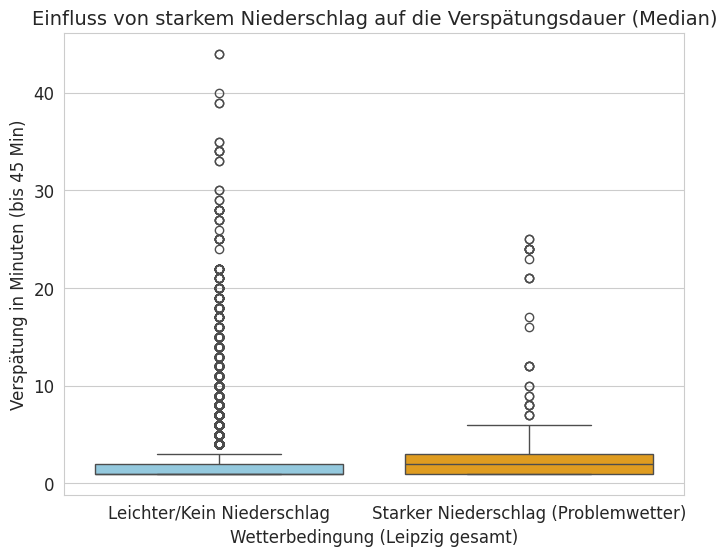

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'is_heavy_precip' in df_final.columns:
    # Berechnung des Medians der Verspätung (als schnelle Zusammenfassung)
    median_delay_by_weather = df_final.groupby('is_heavy_precip')['delay_in_minutes'].median().reset_index()
    print("\nMedian-Verspätung in Minuten, sortiert nach Niederschlag:")
    print(median_delay_by_weather)
    
    # Boxplot Visualisierung
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='is_heavy_precip', y='delay_in_minutes', 
                data=df_final[df_final['delay_in_minutes'] < 45], # Daten auf < 45 Min begrenzen
                palette={'Starker Niederschlag (Problemwetter)': 'orange', 'Leichter/Kein Niederschlag': 'skyblue'})
    
    plt.title('Einfluss von starkem Niederschlag auf die Verspätungsdauer (Median)', fontsize=14)
    plt.xlabel('Wetterbedingung (Leipzig gesamt)', fontsize=12)
    plt.ylabel('Verspätung in Minuten (bis 45 Min)', fontsize=12)
    plt.show()

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# 1. Zielvariable (Target) und Features definieren
df_model = df_final.copy()
# Target: Schwere Verspätung (> 15 Min) = 1
df_model['target_heavy_delay'] = (df_model['delay_category'] == 'Schwer (> 15 Min)').astype(int)

# Features (Merkmale) auswählen
categorical_features = ['day_of_week', 'time_segment', 'is_heavy_precip', 'delay_type', 'station']
numerical_features = ['hour', 'temperature_2m', 'windspeed_10m'] 

X = df_model[categorical_features + numerical_features]
y = df_model['target_heavy_delay']

# 2. Daten in Trainings- und Test-Sets teilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) 

# 3. One-Hot Encoding (Manuell)
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# WICHTIG: Sicherstellen, dass beide DataFrames die gleichen Spalten haben
common_cols = list(set(X_train_encoded.columns) & set(X_test_encoded.columns))
X_train_final = X_train_encoded[common_cols]
X_test_final = X_test_encoded[common_cols]

# 4. Skalierung der numerischen Spalten
scaler = StandardScaler()

scaled_cols = [col for col in X_train_final.columns if any(feat in col for feat in numerical_features)]

# Skalierung nur auf diese numerischen Spalten anwenden
X_train_final[scaled_cols] = scaler.fit_transform(X_train_final[scaled_cols])
X_test_final[scaled_cols] = scaler.transform(X_test_final[scaled_cols])

print(f"Modell-Features vorbereitet. Finale Feature-Anzahl: {X_train_final.shape[1]}")
print(f"Anteil schwerer Verspätungen (Target=1): {y.mean():.2%}")

Modell-Features vorbereitet. Finale Feature-Anzahl: 34
Anteil schwerer Verspätungen (Target=1): 1.38%


/tmp/ipykernel_17261/2406206341.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_final[scaled_cols] = scaler.fit_transform(X_train_final[scaled_cols])


In [46]:
from sklearn.metrics import classification_report, accuracy_score

# 1. Modell initialisieren und trainieren
print("\nStarte Modelltraining...")
# class_weight='balanced' ist entscheidend, da schwere Verspätungen selten sind.
model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced', max_iter=1000)
model.fit(X_train_final, y_train)
print("Modelltraining abgeschlossen.")

# 2. Vorhersagen treffen
y_pred = model.predict(X_test_final)

# 3. Evaluierung des Modells
print("\n--- Modellauswertung ---")
print(f"Genauigkeit (Accuracy): {accuracy_score(y_test, y_pred):.3f}")
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred))

# 4. Interpretation der Koeffizienten (Risikofaktoren)
feature_names = X_train_final.columns.tolist()
coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names, 
    'Koeffizient (Risiko)': coefficients
})

# Berechnung der Odds Ratio (Risikoverhältnis: e^(Koeffizient))
feature_importance['Odds_Ratio'] = np.exp(feature_importance['Koeffizient (Risiko)'])
feature_importance = feature_importance.sort_values(by='Odds_Ratio', ascending=False)

print("\n--- Top 10 Risikofaktoren (Odds Ratio für schwere Verspätung) ---")
print(feature_importance.head(10))


Starte Modelltraining...
Modelltraining abgeschlossen.

--- Modellauswertung ---
Genauigkeit (Accuracy): 0.769

Klassifikationsbericht:
              precision    recall  f1-score   support

           0       0.99      0.77      0.87      4099
           1       0.04      0.70      0.08        57

    accuracy                           0.77      4156
   macro avg       0.52      0.74      0.47      4156
weighted avg       0.98      0.77      0.86      4156


--- Top 10 Risikofaktoren (Odds Ratio für schwere Verspätung) ---
                                              Feature  Koeffizient (Risiko)  \
20  is_heavy_precip_Starker Niederschlag (Problemw...              3.216455   
30                                station_Leipzig Hbf              2.520804   
31                                 day_of_week_Sunday              2.449086   
5                          station_Leipzig-Engelsdorf              2.124256   
1                     station_Flughafen Leipzig/Halle              1.91103